# Theory vs. experiment — the $\ell=1$ focusing scan (`8-17-26 / 29_n15`)

This notebook puts the **theoretical waterfalls** of
[`notebooks/OFVB_mask_amplitude_v5.ipynb`](notebooks/OFVB_mask_amplitude_v5.ipynb) directly next to
the **measured** $\ell=1$ focusing data, everything plotted against the **real axial distance
$z$ (mm)**.

**Theory side** (dimensionless diffraction, reproduced from OFVB): optimize the Bessel parameter
$\beta$, build the three pupil masks **Optimal / PFBZ / FBZ**, and propagate each to an intensity
map. The propagation is done once and cached (see `theory_cache.py`); the axial coordinate is then
placed on the real $z$ (mm) axis (below), so nothing here is shown in the dimensionless $\tau$.

**Experiment side** (verbatim stitched pipeline from `waterfall_stitched_8-17-26.ipynb`):
load the `8-17-26/29_n15/{FBZ,Optimal,PFBZ}` scans for $\ell=1$, track the centroid, take a
transverse slice per frame, and **stitch** the overlapping stage segments onto one global $z$ (mm)
axis. On 8-17-26 every condition was recorded as three segments (`0–25 / 20–45 / 40–65 mm`).

### The one modeling choice: placing theory on the $z$ (mm) axis

The theory is computed on the dimensionless axial coordinate $\tau$, with the design focus at
$\tau_f = 1/(2\pi n_0)$. The raw relation $z = k a^2\tau$ is not physical on this bench (a 4f system
+ final lens rescales the axial coordinate — see the README), so instead we use a single **linear
map through the origin** that anchors the design focus to a reference distance:

$$z \;=\; \tau\cdot\texttt{THEORY\_MM\_PER\_TAU},\qquad \tau_f \leftrightarrow \texttt{Z\_FOCUS\_REF\_MM}.$$

`Z_FOCUS_REF_MM` defaults to 50 mm (≈ the measured focus); it is exposed as a tunable so theory can
be slid along $z$ to match the data. The aperture $a$ sets the transverse mm scale independently.

### Plan / sections

1. **Theory** — $\beta$-optimization, the three masks, propagation (cached), and the three
   theoretical waterfalls drawn on the $z$ (mm) axis.
2. **Theory analysis** — transverse **RMS width (mm) vs $z$** from each theoretical map, and the
   theoretical focus $z$.
3. **Experiment** — the stitched pipeline for $\ell=1$, all three conditions, width vs $z$ (RMS + LG).
4. **Compare** — theory and measured width-vs-$z$ overlaid, and side-by-side waterfalls on a shared
   $z$ (mm) axis.


## Shared configuration

$\ell$, the focusing parameter $n_0$, aperture radius $a$, wavelength, and the camera pixel pitch.
`N0 = 15` matches the `29_n15` mask; `PIXEL_PITCH_MM = 0.0048` is the camera pitch used throughout
the experimental notebooks. Note the theory and camera transverse scales differ by the (unknown) 4f
magnification, so the width comparison later is by *shape*, not absolute mm.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.special import jv
from scipy.optimize import minimize_scalar, curve_fit

import theory_cache   # one-time expensive propagation lives here; see theory_cache.py

plt.rcParams["figure.dpi"] = 130
np.set_printoptions(precision=6, suppress=True)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
SCAN_ROOT = DATA_ROOT / "8-17-26" / "29_n15"
OUT_ROOT = REPO_ROOT / "outputs" / "theory_vs_experiment_l1"
WATERFALL_DIR = OUT_ROOT / "waterfalls"     # shared theory + experiment .npz store
OUT_ROOT.mkdir(parents=True, exist_ok=True)
WATERFALL_DIR.mkdir(parents=True, exist_ok=True)

# --- physical / dimensionless parameters ----------------------------------
L = 1                       # OAM charge for this comparison
N0 = 14                     # focusing parameter (matches OFVB_mask_amplitude_v5)
A = 2.9e-3 *1/4             # aperture radius [m]  -- sets the theory transverse mm scale
LAM = 633e-9                # wavelength [m]
K = 2 * np.pi / LAM         # optical wavenumber [1/m]

TAU_F = 1.0 / (2 * np.pi * N0)
Z_F = K * A**2 * TAU_F      # ideal focal distance -- NOT the bench distance

PIXEL_PITCH_MM = 0.0048     # camera pixel pitch [mm/px]

# --- theory grid (defines the CACHED propagation; see theory_cache.py) -----
# A and the tau->z scale are deliberately NOT here: they are cheap display
# factors applied below, so retuning them never rebuilds the cache.  Changing
# anything in THEORY_GRID (or L / N0) does trigger a one-time rebuild.
THEORY_GRID = dict(NRHO_IN=4000, NRHO_OUT=700, NTAU=320, TAU_MAX_FACTOR=2.0, NBETA_GRID=40001)
FORCE_THEORY_RECOMPUTE = False       # set True for a one-off forced rebuild of the cache

# --- tau -> z (mm) map for THEORY (cheap; independent of the cache) --------
# Put theory on the *real* axial axis (mm), same as the experiment, via one
# global scale anchoring the design focus tau_f to a reference distance.  The
# measured focus sits near 50 mm, so tau_f -> 50 mm aligns the two by default.
Z_FOCUS_REF_MM = 50.0                       # z (mm) that tau_f maps to
THEORY_MM_PER_TAU = Z_FOCUS_REF_MM / TAU_F  # mm per unit tau


def theory_tau_to_z(taus_arr) -> np.ndarray:
    """Map dimensionless tau to real axial distance z [mm] (linear through 0)."""
    return np.asarray(taus_arr, float) * THEORY_MM_PER_TAU


# --- shared waterfall format (theory and experiment saved identically) -----
def save_waterfall_npz(path, *, z_mm, x_mm, waterfall, width_mm, source, condition):
    """Persist a waterfall in the common format: axial z (mm), transverse x (mm),
    intensity map (z x x, peak-normalised) and RMS width vs z (mm)."""
    np.savez_compressed(path, z_mm=np.asarray(z_mm, float), x_mm=np.asarray(x_mm, float),
                        waterfall=np.asarray(waterfall, float),
                        width_mm=np.asarray(width_mm, float),
                        source=str(source), condition=str(condition))


def load_waterfall_npz(path) -> dict:
    with np.load(path, allow_pickle=False) as d:
        return {k: (str(d[k]) if d[k].dtype.kind in "US" else d[k]) for k in d.files}


print(f"l           = {L}")
print(f"n0          = {N0}")
print(f"tau_f       = {TAU_F:.9f}")
print(f"z_f (ideal) = {Z_F:.3f} m   <- not physical here (4f + lens rescales z)")
print(f"pixel pitch = {PIXEL_PITCH_MM} mm/px")
print(f"theory z-map: tau_f -> {Z_FOCUS_REF_MM} mm  ({THEORY_MM_PER_TAU:.1f} mm per tau)")
assert SCAN_ROOT.is_dir(), f"missing {SCAN_ROOT}"

l           = 1
n0          = 14
tau_f       = 0.011368210
z_f (ideal) = 0.059 m   <- not physical here (4f + lens rescales z)
pixel pitch = 0.0048 mm/px
theory z-map: tau_f -> 50.0 mm  (4398.2 mm per tau)


# 1 · Theory (loaded from the one-time cache)

The expensive step — optimising $\beta$, building the Optimal / PFBZ / FBZ masks, and Fresnel-
propagating each to an intensity map — lives in **`theory_cache.py`** and runs **once**, saving the
result to `outputs/theory_vs_experiment_l1/theory_l1_cache.npz`. The cell below just **loads** that
cache (rebuilding only if `THEORY_GRID` / `L` / `N0` change, or `FORCE_THEORY_RECOMPUTE=True`) and
immediately places the axial axis on real distance $z$ (mm) via `z_theory`.

Because the propagation is dimensionless, the aperture $a$ (transverse mm scale) and the axial
$z$-map are applied *after* loading and never trigger a recompute — so retuning $a$ or the axial
scale to match experiment is instant, and everything below is shown in $z$ (mm).

In [2]:
# One-time expensive propagation is cached in theory_cache.py -- this loads it
# and only recomputes if THEORY_GRID / L / N0 change (or FORCE_THEORY_RECOMPUTE).
_cache = theory_cache.load_or_build(
    params=dict(L=L, N0=N0, **THEORY_GRID),
    force=FORCE_THEORY_RECOMPUTE,
)
assert np.isclose(float(_cache["tau_f"]), TAU_F), "cache tau_f disagrees with config N0"

taus = _cache["taus"]                              # dimensionless axial grid (internal only)
rho_out = _cache["rho_out"]
THEORY = _cache["intensity"]                       # {condition: intensity map (axial, rho)}
beta_opt = float(_cache["beta_opt"])
theta = float(_cache["theta"])
rho_star = float(_cache["rho_star"])
r_star = A * rho_star

TAU_MAX = THEORY_GRID["TAU_MAX_FACTOR"] * TAU_F
z_theory = theory_tau_to_z(taus)                   # theory axial axis in mm (used everywhere below)
Z_MAX = float(z_theory[-1])

print(f"beta_opt = {beta_opt:.9f}   theta = {theta:.6f} rad")
print(f"rho_star = {rho_star:.6f}  ->  ring radius r_star = {1e3 * r_star:.4f} mm")
for name, I in THEORY.items():
    print(f"  {name:>8}: intensity map {I.shape}  peak-normalised")
print(f"theory axial axis: z = 0 .. {Z_MAX:.1f} mm   (focus at {Z_FOCUS_REF_MM:.0f} mm)")

loaded theory cache theory_l1_cache.npz (params match, no recompute)
beta_opt = 2.391468288   theta = -0.820723 rad
rho_star = 0.027187  ->  ring radius r_star = 0.0197 mm
   Optimal: intensity map (320, 700)  peak-normalised
      PFBZ: intensity map (320, 700)  peak-normalised
       FBZ: intensity map (320, 700)  peak-normalised
theory axial axis: z = 0 .. 100.0 mm   (focus at 50 mm)


## 1.4 Theoretical waterfalls on the $z$ (mm) axis

Transverse cross-section $I(z, x)$ along $y=0$ for each mask, with $x = a\rho$ (mm) and the axial
axis mapped to real distance via $z = \tau\cdot$`THEORY_MM_PER_TAU`. The design focus (at
`Z_FOCUS_REF_MM`) is dashed.

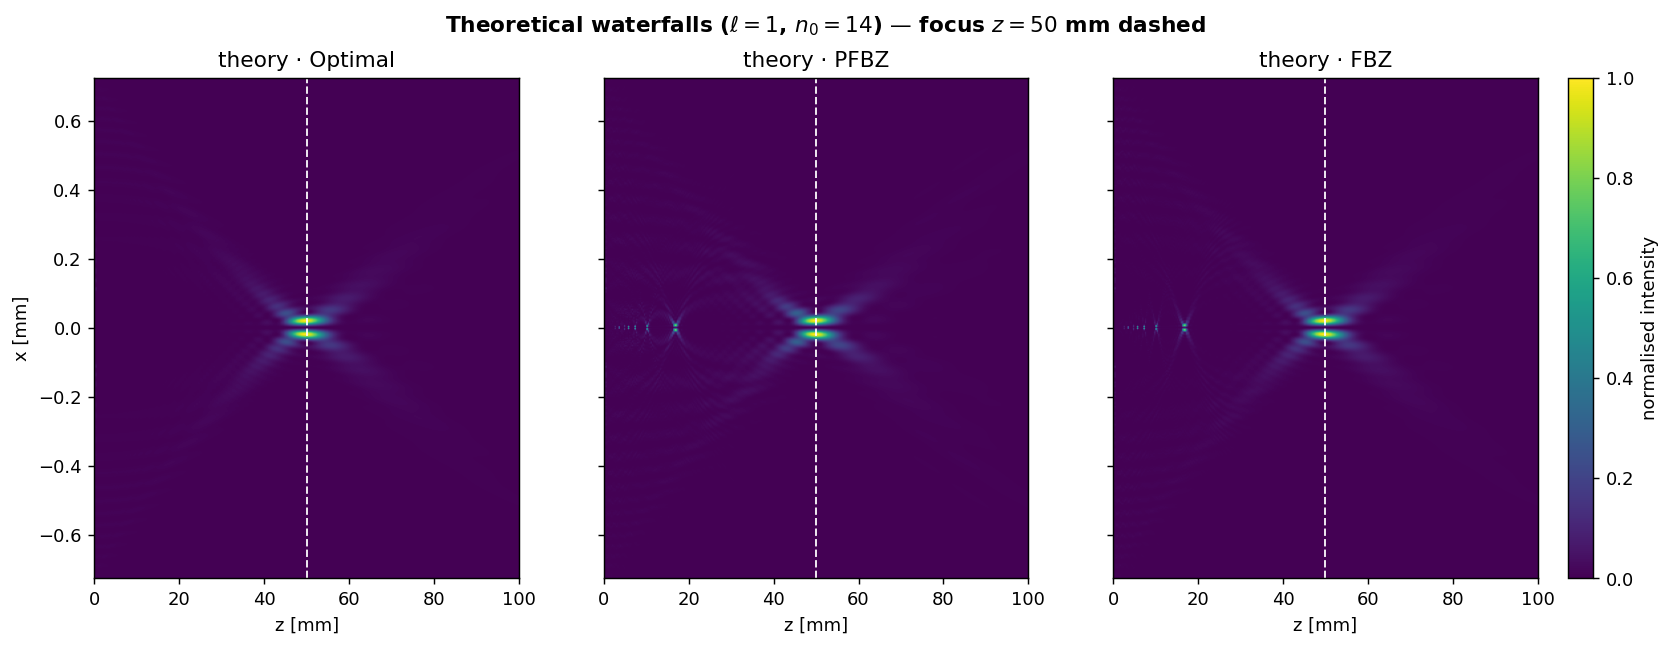

In [3]:
def theory_x_map(intensity_map, rho_out, n_x=901):
    """Mirror the radial map to a symmetric transverse profile I(z, x), x in mm."""
    x_unit = np.linspace(-1.0, 1.0, n_x)
    x_mm = 1e3 * A * x_unit
    img = np.zeros((len(taus), n_x))
    for j in range(len(taus)):
        img[j] = np.interp(np.abs(x_unit), rho_out, intensity_map[j])
    return x_mm, img


fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), sharey=True)
for ax, (name, I) in zip(axes, THEORY.items()):
    x_mm, img = theory_x_map(I, rho_out)
    im = ax.imshow(img.T, origin="lower", aspect="auto",
                   extent=[z_theory[0], z_theory[-1], x_mm[0], x_mm[-1]],
                   cmap="viridis", vmin=0, vmax=1)
    ax.axvline(Z_FOCUS_REF_MM, color="w", ls="--", lw=1.1, alpha=0.9)
    ax.set_xlabel("z [mm]")
    ax.set_title(f"theory · {name}")
    ax.set_ylim(-1e3 * A, 1e3 * A)           # full aperture scale (matches v5)
axes[0].set_ylabel("x [mm]")
fig.colorbar(im, ax=axes, label="normalised intensity", fraction=0.025, pad=0.02)
fig.suptitle(f"Theoretical waterfalls ($\\ell={L}$, $n_0={N0}$) — focus $z={Z_FOCUS_REF_MM:.0f}$ mm dashed",
             fontweight="bold")
fig.savefig(OUT_ROOT / "theory_waterfalls.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.5 Theory beam-width vs $z$ (mm)

The theory analogue of the measured focus curve, on the real axial axis. Two width measures per
mask, over the **full aperture** (no experimental crop):

* **radial RMS radius** — area-weighted ($\rho\,d\rho$) RMS of the intensity map; its minimum is the
  theoretical focus and lands at `Z_FOCUS_REF_MM` by construction.
* **ring radius** — radius of peak intensity, searched only in the focal band $z>0.3\,$`Z_FOCUS_REF_MM`
  to avoid the on-axis artefact as $z\to0$; equals `r_star` at focus.

Absolute mm here are **theory-plane** mm set by the tuned aperture $a$; with $a$ chosen to match, the
width scale and the axial focus both line up with experiment.

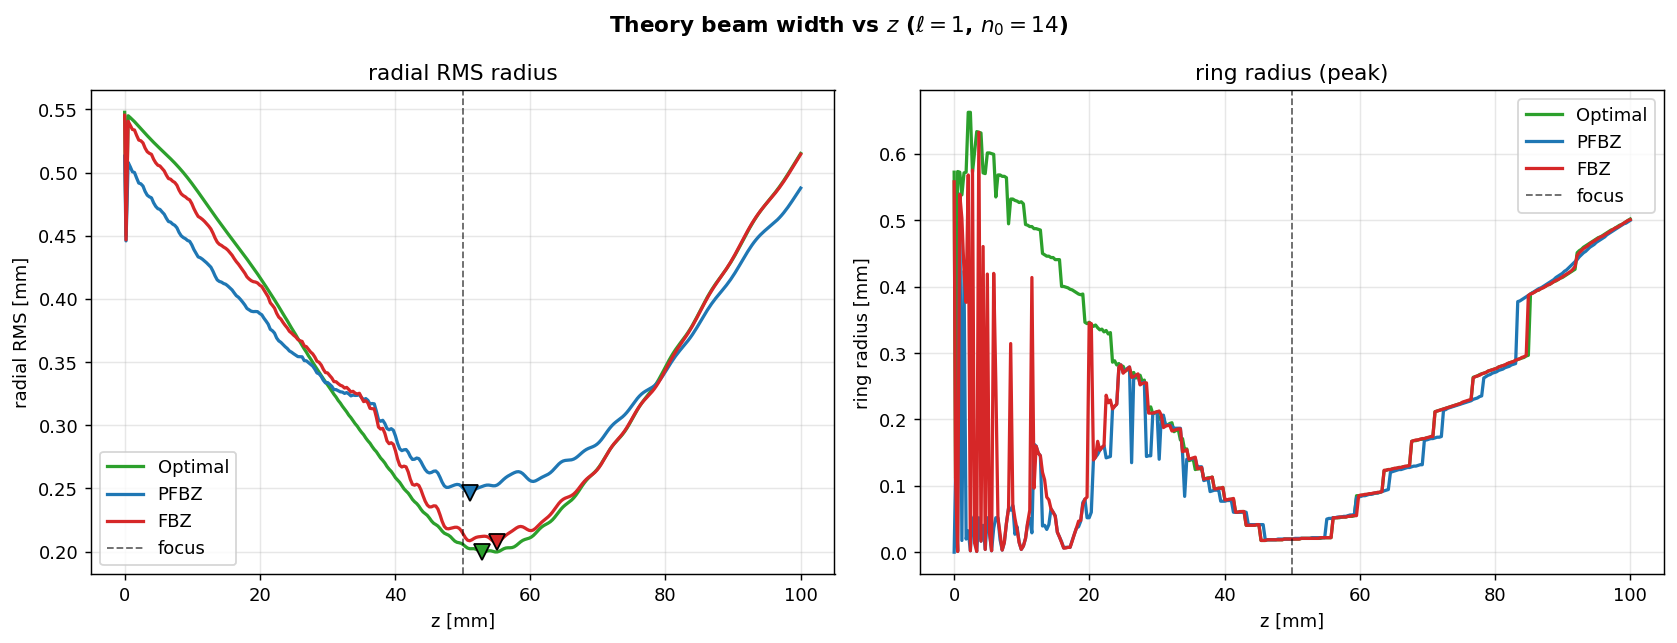

theoretical focus (min radial RMS, in the focal band):
   Optimal: z_focus = 52.92 mm
      PFBZ: z_focus = 51.04 mm
       FBZ: z_focus = 55.12 mm


In [4]:
def theory_radial_rms_mm(intensity_row):
    x_mm = 1e3 * A * rho_out
    w = np.clip(intensity_row, 0, None) * rho_out      # area weight rho drho
    tot = w.sum()
    return float(np.sqrt((w * x_mm**2).sum() / tot)) if tot > 0 else np.nan


def theory_ring_mm(intensity_row):
    return float(1e3 * A * rho_out[int(np.argmax(intensity_row))])


THEORY_WIDTH = {name: np.array([theory_radial_rms_mm(I[j]) for j in range(len(taus))])
                for name, I in THEORY.items()}
THEORY_RING = {name: np.array([theory_ring_mm(I[j]) for j in range(len(taus))])
               for name, I in THEORY.items()}
THEORY_FOCUS = {}   # cond -> theory focus z [mm]

focus_band = z_theory > 0.3 * Z_FOCUS_REF_MM          # ignore the z->0 on-axis artefact
tcol = {"Optimal": "C2", "PFBZ": "C0", "FBZ": "C3"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
for name in THEORY:
    w, ring = THEORY_WIDTH[name], THEORY_RING[name]
    j = int(np.nanargmin(np.where(focus_band, w, np.inf)))
    THEORY_FOCUS[name] = float(z_theory[j])
    axes[0].plot(z_theory, w, "-", lw=1.8, color=tcol[name], label=name)
    axes[0].plot(z_theory[j], w[j], "v", color=tcol[name], ms=9, markeredgecolor="k", zorder=5)
    axes[1].plot(z_theory, ring, "-", lw=1.8, color=tcol[name], label=name)
for ax, ttl, yl in zip(axes, ["radial RMS radius", "ring radius (peak)"],
                       ["radial RMS [mm]", "ring radius [mm]"]):
    ax.axvline(Z_FOCUS_REF_MM, color="k", ls="--", lw=1.0, alpha=0.6, label="focus")
    ax.set_xlabel("z [mm]"); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle(f"Theory beam width vs $z$ ($\\ell={L}$, $n_0={N0}$)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "theory_width_vs_z.png", dpi=150, bbox_inches="tight")
plt.show()

print("theoretical focus (min radial RMS, in the focal band):")
for name, z in THEORY_FOCUS.items():
    print(f"  {name:>8}: z_focus = {z:.2f} mm")

# 2 · Experiment — the stitched $\ell=1$ scan

Everything below is the **verbatim** pipeline of `waterfall_stitched_8-17-26.ipynb`, configured for
$\ell=1$ and all three conditions. On 8-17-26 every condition is three segments (`0–25 / 20–45 /
40–65 mm`).

## 2.1 Acquisition / pipeline constants (verbatim)

In [5]:
RUN = "29_n15_8-17-26"

def nominal_start(folder_name: str) -> float:
    m = re.match(r"(\d+)mm-(\d+)mm", folder_name)
    if not m:
        raise ValueError(f"cannot parse a nominal start from folder {folder_name!r}")
    return float(m.group(1))

# 8-17-26 recorded three segments for every condition (no extended Optimal segment).
CONDITION_SEGMENTS = {
    "FBZ":     ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "Optimal": ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "PFBZ":    ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
}
ELLS = [1]                           # this comparison is l=1 only

STEP_MM = 0.5

# --- slicing (verbatim) ---------------------------------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200

assert SLICE_AXIS in ("x", "y")


# --- Global segment starts (needed early: the "continuous" centroid fit ties
#     the segments together on ONE shared z axis, so it must know where each
#     segment sits before the waterfall is built).  Read the calibrated
#     waterfall_offsets_8-17-26.csv; fall back to DEFAULT_START otherwise. ---
OFFSETS_FILE = REPO_ROOT / "waterfall_offsets_8-17-26.csv"
DEFAULT_START = {"0mm-25mm": 0.0, "20mm-45mm": 24.0, "40mm-65mm": 44.5, "60mm-85mm": 64.5}

_OFFSETS: dict[tuple[str, int, str], float] = {}
if OFFSETS_FILE.is_file():
    _prev = pd.read_csv(OFFSETS_FILE)
    for _, _r in _prev.iterrows():
        _OFFSETS[(str(_r["condition"]), int(_r["ell"]), str(_r["segment"]))] = float(_r["start_mm"])


def global_start(cond: str, ell: int, seg: str) -> float:
    """Absolute global start (mm) of a segment: calibrated CSV value if present,
    else DEFAULT_START, else the folder's nominal start."""
    return _OFFSETS.get((cond, ell, seg), DEFAULT_START.get(seg, nominal_start(seg)))


# --- Centroid tracking mode -------------------------------------------------
# Each frame is re-centred on its OWN fitted centroid, so what must be smooth
# for a seamless waterfall is the RESIDUAL (true centroid - fitted line), not
# the fitted centroid in pixel space.  That reframes the seam problem:
#
# "per_frame":  locate the beam centroid independently in every frame.  Smooth
#               nowhere -- carries the frame-to-frame shot-noise wobble.
# "line":       straight line centroid(z) = slope*z + offset, fit with its OWN
#               slope and offset PER SECTION (the default).  The per-section
#               OFFSET absorbs the ~20 px sideways jump the beam takes each time
#               the stage is repositioned between segments, so the residual is
#               driven to ~0 inside every segment and the beam is continuous
#               (flat at x=0) ACROSS the seams -- no wobble and no step
#               (measured seam shift ~0.003 mm here).
# "parabola":   like "line", but the per-section fit is a QUADRATIC
#               centroid(z) = a*z**2 + b*z + c (own coefficients per section).
#               The curvature term lets the fitted centroid BEND to follow a
#               gently curved beam walk-off, soaking up whatever smooth
#               discrepancy the straight line leaves in the residual, while c
#               still absorbs the per-segment repositioning jump.
# "continuous": ONE piecewise-linear centroid tied to be EQUAL at every handoff.
#               COUNTER-PRODUCTIVE for repositioned segments: forcing the fitted
#               centroid continuous across the repositioning offset makes a
#               single line pass BETWEEN the offset segment clouds, so neither is
#               centred in the overlap and a ~0.1 mm step reappears at each seam.
#               Use only when segments are already co-registered (no offset).
CENTROID_MODE = "parabola"   # "per_frame" | "line" | "parabola" | "continuous"


## 2.2 Frame loading, background, centroid — verbatim

In [6]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    cond: str
    seg: str
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.parent.name}/{directory.name}: positions.csv incomplete -- using index*{STEP_MM}")
    else:
        print(f"  ! {directory.parent.name}/{directory.name}: no positions.csv -- using index*{STEP_MM}")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## 2.3 Process one segment into a waterfall + width trace — verbatim

In [7]:
@dataclass
class SegWaterfall:
    cond: str
    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray
    s_px: np.ndarray
    z_local: np.ndarray
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray
    onaxis: np.ndarray


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(segment: Segment):
    """Pass 1: load a segment's frames and return (z_local, centroid_y,
    centroid_x, weight) -- the RAW per-frame centroid and brightness, before the
    shared straight-line fit.  Frames are released on return."""
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(segment: Segment, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall using the supplied FITTED straight-
    line centroid (centroid_y, centroid_x) for the slice row and the transverse
    centring -- so the beam no longer wobbles frame-to-frame.  Frames are
    reloaded here (they were released after the raw-centroid pass) to keep peak
    memory at a single segment."""
    paths = frame_paths(segment.directory)
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        cond=segment.cond, seg=segment.seg, ell=segment.ell,
        nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px, onaxis=onaxis,
    )


## 2.4 Process every segment (the slow cell — a couple of minutes)

In [8]:
# Straight-line centroid, fit per condition, then build every segment on that
# smooth line so the beam no longer wobbles frame-to-frame.
#   pass 1: raw per-frame centroid + brightness for every segment of a condition
#   fit:    a centroid(z) model per condition for both centroid axes --
#             "line"       -> own slope+offset per section (jumps at the seams)
#             "parabola"   -> own quadratic a*z**2+b*z+c per section (bends to
#                             follow a curved walk-off; jumps at the seams)
#             "continuous" -> ONE continuous piecewise-linear curve on the shared
#                             GLOBAL z, tied to be equal at each handoff (no jump)
#   pass 2: rebuild each segment's waterfall on its fitted centroid line
# (frames are reloaded in pass 2, so peak memory stays at a single segment).
from centroid_lines import (fit_centroid_lines, fit_centroid_parabolas,
                            fit_centroid_lines_continuous)

data: dict[str, dict[int, dict[str, SegWaterfall]]] = {}

for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond

    raw_sections: dict[tuple[int, str], dict] = {}
    segments: dict[tuple[int, str], Segment] = {}
    for ell in ELLS:
        for seg in seg_labels:
            directory = cdir / seg / f"l={ell}"
            if not directory.is_dir():
                continue
            segment = Segment(cond, seg, ell, directory, nominal_start(seg))
            z_local, cy, cx, w = segment_raw_centroids(segment)
            raw_sections[(ell, seg)] = dict(z=z_local, cy=cy, cx=cx, w=w)
            segments[(ell, seg)] = segment
    if not raw_sections:
        continue

    # Fit the chosen centroid model.  "continuous" must see one shared axis, so
    # it is fed GLOBAL z (= z_local + segment start); the returned centroid lines
    # are pixel values indexed like z_local, so pass 2 uses them unchanged.
    if CENTROID_MODE == "continuous":
        gsections = {k: {**raw_sections[k],
                         "z": raw_sections[k]["z"] + global_start(cond, k[0], k[1])}
                     for k in raw_sections}
        lines = fit_centroid_lines_continuous(gsections)[0]
    elif CENTROID_MODE == "parabola":
        lines = fit_centroid_parabolas(raw_sections)[0]
    elif CENTROID_MODE == "line":
        lines = fit_centroid_lines(raw_sections, shared_slope=False)[0]
    else:
        lines = None

    data[cond] = {ell: {} for ell in ELLS}
    for (ell, seg), segment in segments.items():
        r = raw_sections[(ell, seg)]
        cy_use, cx_use = (lines[(ell, seg)] if lines is not None
                          else (r["cy"], r["cx"]))
        data[cond][ell][seg] = process_segment(
            segment, cy_use, cx_use, r["cy"], r["cx"], r["w"])
    data[cond] = {ell: segs for ell, segs in data[cond].items() if segs}

    for ell in data[cond]:
        print(f"{cond:>8}  l={ell}  segs={list(data[cond][ell])}  mode={CENTROID_MODE}")


     FBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']  mode=parabola


 Optimal  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']  mode=parabola


    PFBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']  mode=parabola


## 2.5 Segment offsets from `waterfall_offsets_8-17-26.csv`

Absolute global starts per `(condition, ell, segment)`, taken from the calibrated
`waterfall_offsets_8-17-26.csv` produced by the stitched notebook. Any `(cond, ell, seg)` missing
from the file falls back to `DEFAULT_START`; edit the CSV and re-run if a segment needs nudging.

In [9]:
# Absolute global start per (condition, ell, segment), from the same
# `global_start` used by the continuous centroid fit above (calibrated
# waterfall_offsets_8-17-26.csv, else DEFAULT_START).  Edit the CSV and re-run
# if a segment needs nudging.
STARTS_MM: dict[str, dict[int, dict[str, float]]] = {}
for cond in data:
    STARTS_MM[cond] = {}
    for ell in data[cond]:
        STARTS_MM[cond][ell] = {seg: global_start(cond, ell, seg)
                                for seg in data[cond][ell]}

for cond in STARTS_MM:
    for ell in STARTS_MM[cond]:
        print(f"{cond:>8} l={ell}: " + ", ".join(f"{s}@{v:.1f}" for s, v in STARTS_MM[cond][ell].items()))

     FBZ l=1: 0mm-25mm@0.0, 20mm-45mm@24.0, 40mm-65mm@43.5
 Optimal l=1: 0mm-25mm@0.0, 20mm-45mm@24.0, 40mm-65mm@43.5
    PFBZ l=1: 0mm-25mm@0.0, 20mm-45mm@24.0, 40mm-65mm@43.5


## 2.6 Stitch helpers — verbatim

In [10]:
def seg_order(cond: str, ell: int) -> list[str]:
    return [s for s in CONDITION_SEGMENTS[cond] if s in data[cond][ell]]


def global_z(sw: SegWaterfall, ell: int) -> np.ndarray:
    return sw.z_local + STARTS_MM[sw.cond][ell][sw.seg]


BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    cond: str
    ell: int
    mode: str
    waterfall: np.ndarray
    s_px: np.ndarray
    z_mm: np.ndarray
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    coverage: np.ndarray

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src, water_src, z_grid):
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1)
    return out, covered


def _blend_weights(mode, order, z_grid, covers):
    order = [lbl for lbl in order if lbl in covers]
    w = {lbl: covers[lbl].astype(float) for lbl in order}
    if mode == "average":
        pass
    elif mode == "hardcut":
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            mid = 0.5 * (z_ov.min() + z_ov.max())
            w[left][both] = np.where(z_ov <= mid, 1.0, 0.0)
            w[right][both] = np.where(z_ov <= mid, 0.0, 1.0)
    else:  # crossfade
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp
    stack = np.stack([w[lbl] for lbl in order])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return {lbl: stack[i] for i, lbl in enumerate(order)}


def stitch(cond, ell, mode, z_grid):
    order = seg_order(cond, ell)
    sws = {lbl: data[cond][ell][lbl] for lbl in order}
    s_px = sws[order[0]].s_px
    for lbl, sw in sws.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped differently"
    maps, covers, zs = {}, {}, {}
    for lbl, sw in sws.items():
        z = global_z(sw, ell)
        m, cov = _resample_map(z, sw.waterfall, z_grid)
        maps[lbl], covers[lbl], zs[lbl] = m, cov, z
    weights = _blend_weights(mode, order, z_grid, covers)
    water = np.zeros_like(maps[order[0]])
    for lbl in order:
        water += weights[lbl][:, None] * maps[lbl]
    covered_any = np.any([covers[lbl] for lbl in order], axis=0)
    water[~covered_any] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak
    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in order:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_x)
    coverage = np.sum([covers[lbl] for lbl in order], axis=0)
    return Stitched(cond, ell, mode, water, s_px, z_grid, cy, cx, coverage)

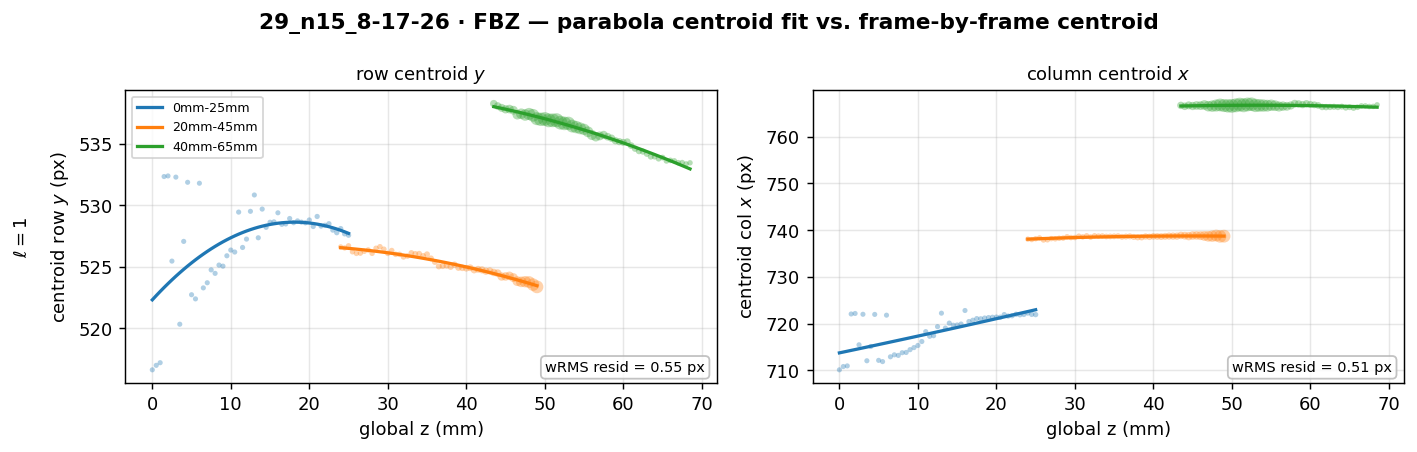

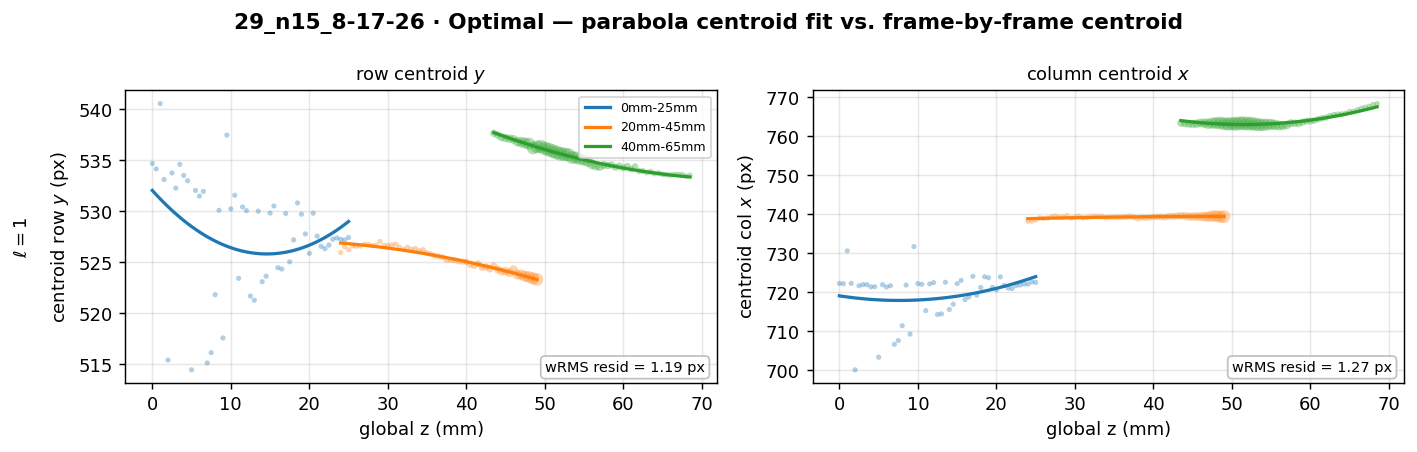

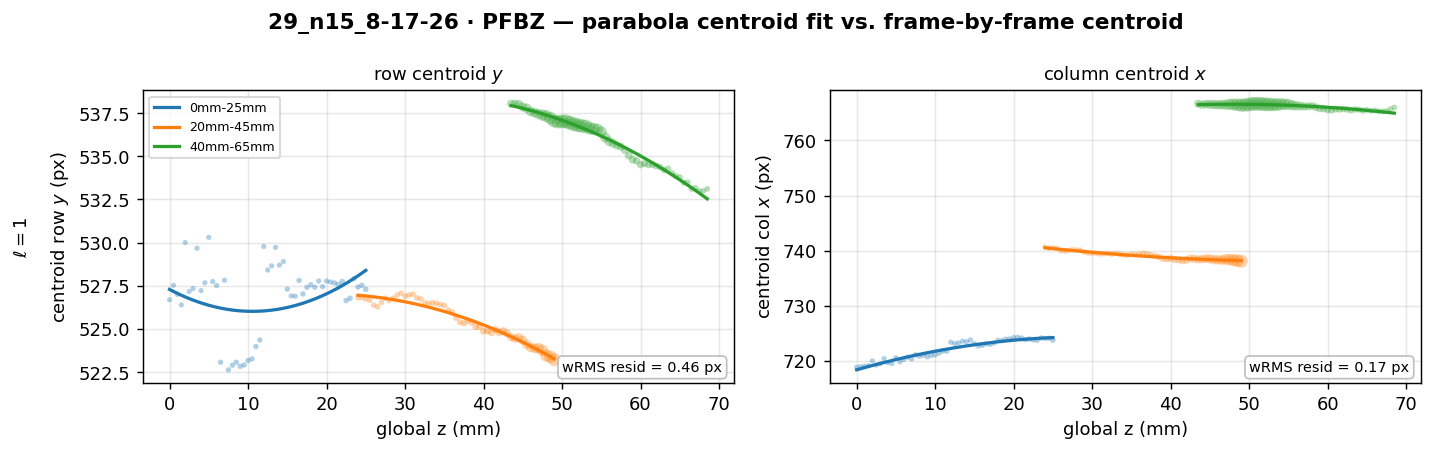

In [11]:
# --- Diagnostic: fitted centroid line vs. frame-by-frame centroid ------------
# Points are the raw per-frame centroids (area ~ brightness weight); the line is
# the fit that actually built the waterfalls.  In "continuous" mode the sections
# are tied into one curve on the shared global z, so neighbouring lines MEET at
# each handoff (no jump); "parabola" overlays the per-section quadratic;
# "line"/"per_frame" fall back to the independent per-section line so the model
# can still be judged.
from centroid_lines import (fit_sections_for_plot, fit_sections_for_plot_parabola,
                            fit_sections_for_plot_continuous, plot_centroid_fit)

_CENTROID_PREP = {
    "continuous": fit_sections_for_plot_continuous,
    "parabola": fit_sections_for_plot_parabola,
}

def plot_centroid_fit_cond(cond):
    prep = _CENTROID_PREP.get(CENTROID_MODE, fit_sections_for_plot)
    groups = {}
    for ell in data[cond]:
        raw = {seg: dict(z=global_z(sw, ell), cy=sw.centroid_y_raw,
                         cx=sw.centroid_x_raw, w=sw.centroid_w)
               for seg, sw in data[cond][ell].items()}
        groups[f"$\\ell={ell}$"] = prep(raw)
    plot_centroid_fit(
        groups, path=OUT_ROOT / f"{cond}_centroid_fit.png",
        title=f"{RUN} · {cond} — {CENTROID_MODE} centroid fit vs. frame-by-frame centroid")

for cond in CONDITION_SEGMENTS:
    if data.get(cond):
        plot_centroid_fit_cond(cond)


## 2.7 Build the stitched $\ell=1$ waterfalls

One global grid per condition; `CHOSEN_BLEND = "hardcut"` as in the source notebook.

In [12]:
CHOSEN_BLEND = "hardcut"

stitched: dict[str, Stitched] = {}
for cond in CONDITION_SEGMENTS:
    ell = ELLS[0]
    order = seg_order(cond, ell)
    z_hi = max(global_z(data[cond][ell][s], ell)[-1] for s in order)
    z_lo = min(global_z(data[cond][ell][s], ell)[0] for s in order)
    grid = np.arange(z_lo, z_hi + 0.5 * STEP_MM, STEP_MM)
    st = stitch(cond, ell, CHOSEN_BLEND, grid)
    stitched[cond] = st
    print(f"{cond:>8}: {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm  "
          f"brightest {st.brightest_z:.1f} mm")

     FBZ: (138, 401)  z 0.0..68.5 mm  brightest 51.0 mm
 Optimal: (138, 401)  z 0.0..68.5 mm  brightest 51.5 mm
    PFBZ: (138, 401)  z 0.0..68.5 mm  brightest 50.5 mm


## 2.8 Measured beam width vs $z$ (RMS + LG-$\ell$ fit)

RMS radius per stitched frame, plus the per-frame LG($\ell=1$) waist fit (verbatim from the source
notebook) whose RMS model is the physically correct width for a doughnut. We keep both curves in
pixels here; the mm conversion and shared-format packaging happen in section 3.

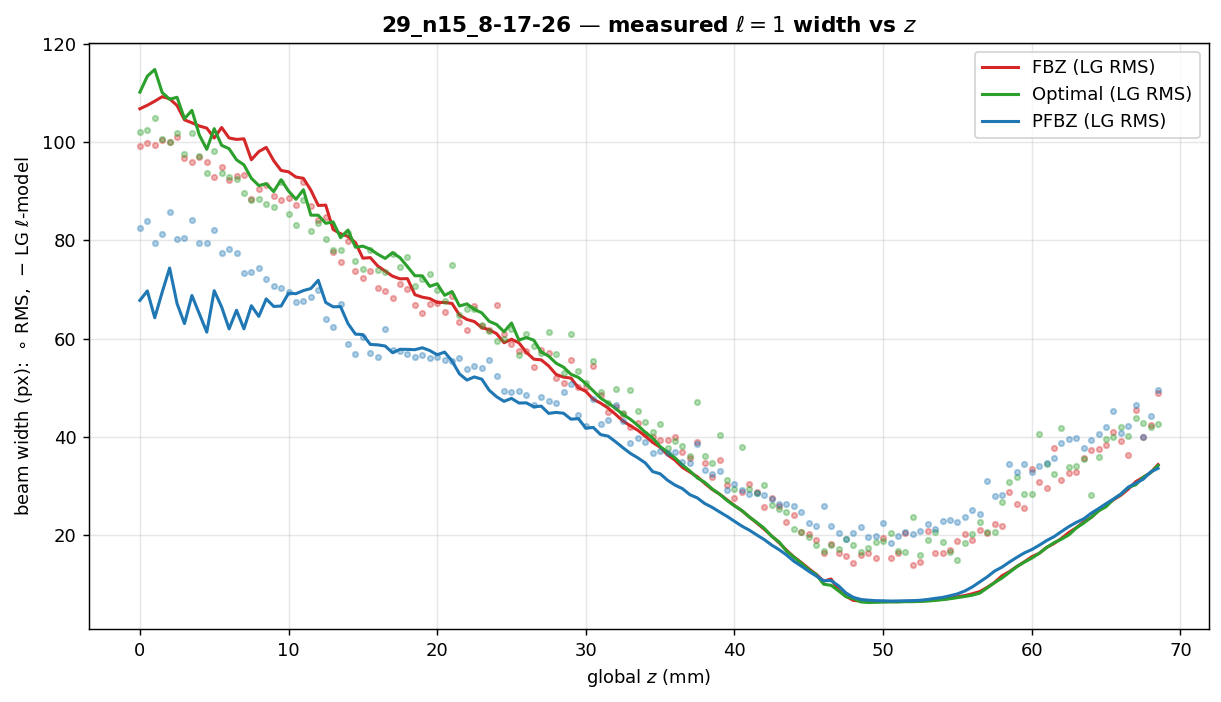

In [13]:
def lg_line_profile(s, amp, w, ell):
    x = 2.0 * (np.asarray(s, float) ** 2) / (w * w)
    return amp * x ** abs(ell) * np.exp(-x)


def lg_rms_from_w(w, ell):
    return 0.5 * np.asarray(w, float) * np.sqrt(2 * abs(ell) + 1)


def fit_lg_frame(profile, s_px, ell):
    y = np.clip(np.asarray(profile, float), 0, None)
    if not np.isfinite(y).any() or y.max() <= 0:
        return np.nan
    rms = _rms_width(y, s_px)
    if not np.isfinite(rms) or rms <= 0:
        return np.nan
    w0 = 2.0 * rms / np.sqrt(2 * abs(ell) + 1)
    amp0 = y.max() / max((abs(ell) ** abs(ell)) * np.exp(-abs(ell)), 1e-9)
    try:
        popt, _ = curve_fit(partial(lg_line_profile, ell=ell), s_px, y,
                            p0=(amp0, max(w0, 1.0)),
                            bounds=([0.0, 1e-3], [np.inf, np.inf]), maxfev=10000)
    except (RuntimeError, ValueError):
        return np.nan
    return float(popt[1])


def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])


def lg_fit_stitched(st):
    w_fit = np.array([
        fit_lg_frame(row, st.s_px, st.ell) if cov > 0 else np.nan
        for row, cov in zip(st.waterfall, st.coverage)])
    return w_fit, lg_rms_from_w(w_fit, st.ell)


EXP_WIDTH = {}   # cond -> dict(z_mm, rms_px, lg_rms_px)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ecol = {"Optimal": "C2", "PFBZ": "C0", "FBZ": "C3"}
for cond, st in stitched.items():
    rms = stitched_width(st)
    _, lg_rms = lg_fit_stitched(st)
    EXP_WIDTH[cond] = {"z_mm": st.z_mm, "rms_px": rms, "lg_rms_px": lg_rms, "coverage": st.coverage}
    ax.plot(st.z_mm, rms, "o", ms=3, color=ecol[cond], alpha=0.35)
    ax.plot(st.z_mm, lg_rms, "-", lw=1.7, color=ecol[cond], label=f"{cond} (LG RMS)")
ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel(r"beam width (px):  $\circ$ RMS,  $-$ LG $\ell$-model")
ax.set_title(f"{RUN} — measured $\\ell={ELLS[0]}$ width vs $z$", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "exp_width_vs_z.png", dpi=150, bbox_inches="tight")
plt.show()

# 3 · Compare on the real $z$ (mm) axis

Both theory and experiment now live on the same axial axis in **mm** — theory via
$z=\tau\cdot$`THEORY_MM_PER_TAU`, experiment natively. The cell below packs each into the shared
waterfall format (`z_mm`, `x_mm`, `waterfall`, `width_mm`) and saves them to
`outputs/theory_vs_experiment_l1/waterfalls/` (`theory_*.npz`, `exp_*.npz`), so theory and
experiment are literally interchangeable on disk. It also reports each condition's measured vs
theoretical focus $z$.

In [14]:
# Assemble theory + experiment into ONE shared format (z_mm, x_mm, waterfall,
# width_mm) and persist each to outputs/.../waterfalls/*.npz.  Both sources now
# live on the real z (mm) axis, so everything downstream treats them identically.

def exp_focus_z(cond):
    """Measured LG focus (z of minimum LG-RMS width) for a condition."""
    d = EXP_WIDTH[cond]
    w = d["lg_rms_px"].astype(float).copy()
    w[d["coverage"] <= 0] = np.nan
    return float(d["z_mm"][np.nanargmin(w)])


THEORY_WF: dict[str, dict] = {}   # cond -> shared-format dict (theory)
EXP_WF: dict[str, dict] = {}      # cond -> shared-format dict (experiment)

for name in THEORY:
    x_mm, img = theory_x_map(THEORY[name], rho_out)          # img: (z, x), peak-normalised
    THEORY_WF[name] = dict(z_mm=z_theory, x_mm=x_mm, waterfall=img,
                           width_mm=THEORY_WIDTH[name], source="theory")
    save_waterfall_npz(WATERFALL_DIR / f"theory_{name}.npz", source="theory", condition=name,
                       z_mm=z_theory, x_mm=x_mm, waterfall=img, width_mm=THEORY_WIDTH[name])

for cond, st in stitched.items():
    x_mm = st.s_px * PIXEL_PITCH_MM
    width_mm = EXP_WIDTH[cond]["lg_rms_px"] * PIXEL_PITCH_MM   # LG RMS (clip-robust) in camera mm
    EXP_WF[cond] = dict(z_mm=st.z_mm, x_mm=x_mm, waterfall=st.waterfall,
                        width_mm=width_mm, source="experiment")
    save_waterfall_npz(WATERFALL_DIR / f"exp_{cond}.npz", source="experiment", condition=cond,
                       z_mm=st.z_mm, x_mm=x_mm, waterfall=st.waterfall, width_mm=width_mm)

print(f"saved {len(THEORY_WF)} theory + {len(EXP_WF)} experiment waterfalls -> {WATERFALL_DIR}")
print(f"{'cond':>8}  {'exp focus':>10}  {'theory focus':>13}")
for cond in EXP_WF:
    print(f"{cond:>8}  {exp_focus_z(cond):8.1f} mm  {THEORY_FOCUS[cond]:10.1f} mm")

saved 3 theory + 3 experiment waterfalls -> /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/theory_vs_experiment_l1/waterfalls
    cond   exp focus   theory focus
     FBZ      50.5 mm        55.1 mm
 Optimal      49.0 mm        52.9 mm
    PFBZ      50.5 mm        51.0 mm


## 3.2 Width vs $z$ — theory overlaid on measured

The headline comparison, now in absolute mm on the real $z$ axis. **Left:** beam width (mm) vs $z$ —
theory radial RMS (dashed) and measured LG RMS (solid); with the aperture $a$ tuned, the theory mm
scale and axial focus line up with experiment directly. **Right:** the same curves each normalised to
their own focal minimum, isolating the *shape* of focusing (depth of focus and divergence rate),
independent of any residual scale offset. Focus $z$ is marked.

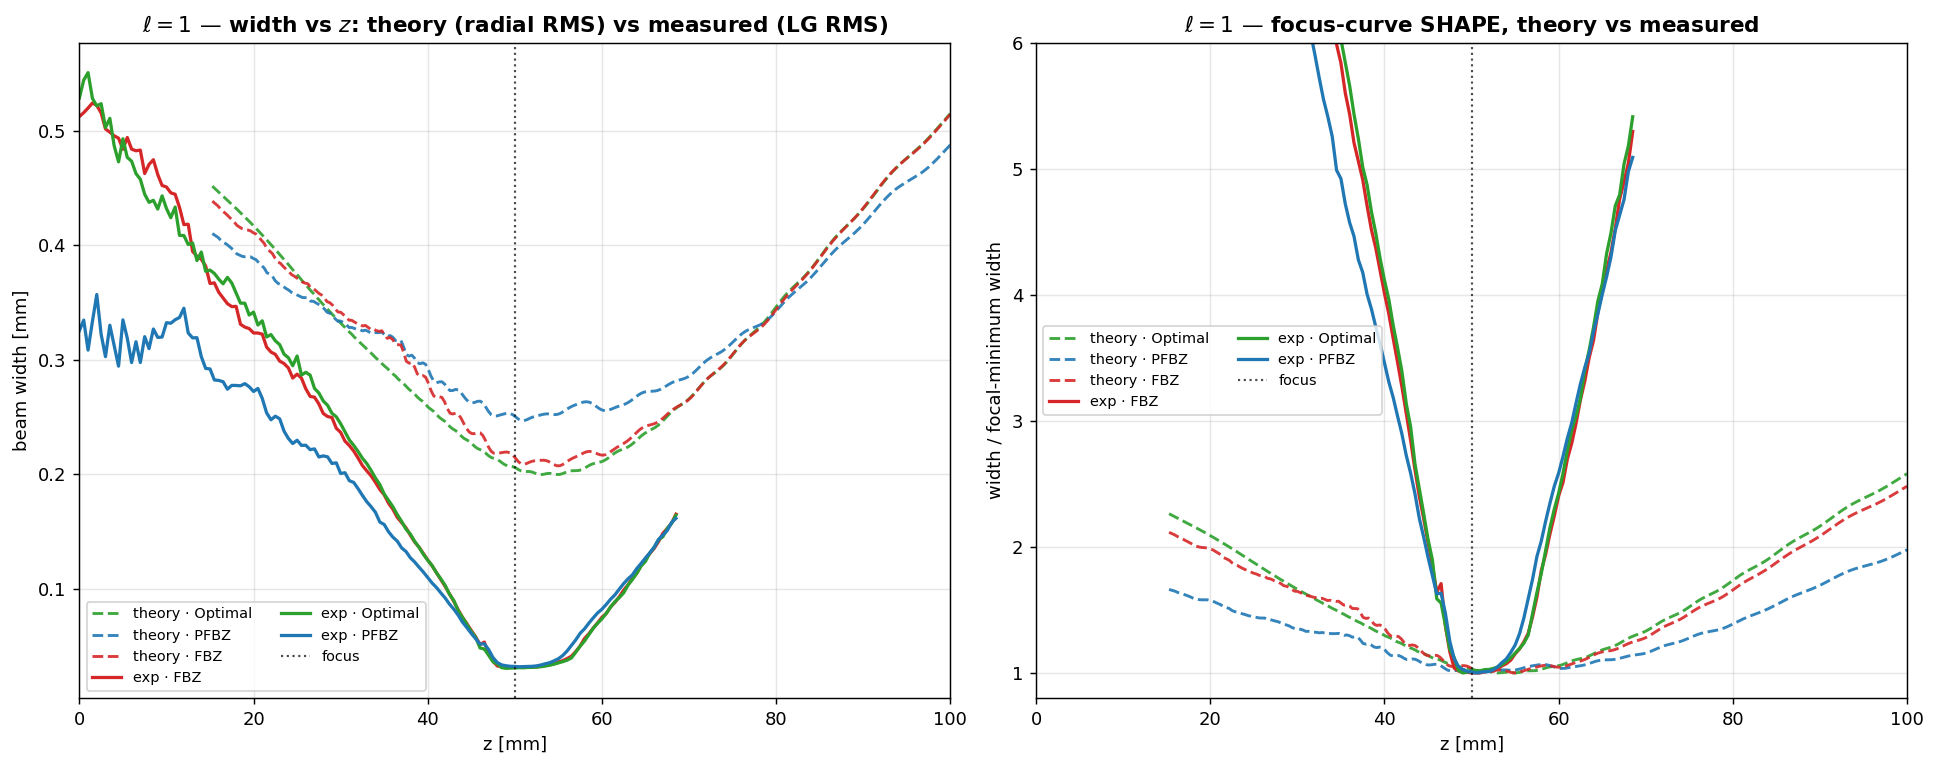

In [15]:
def norm_to_min(y):
    y = np.asarray(y, float)
    m = np.nanmin(y)
    return y / m if m and np.isfinite(m) else y


Z_ARTEFACT = 0.3 * Z_FOCUS_REF_MM     # mask the z->0 on-axis artefact

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left: absolute width in mm vs z ---------------------------------------
ax = axes[0]
for name, wf in THEORY_WF.items():
    w = np.where(wf["z_mm"] > Z_ARTEFACT, wf["width_mm"], np.nan)
    ax.plot(wf["z_mm"], w, "--", lw=1.6, color=tcol[name], alpha=0.9, label=f"theory · {name}")
for cond, wf in EXP_WF.items():
    ax.plot(wf["z_mm"], wf["width_mm"], "-", lw=1.8, color=ecol[cond], label=f"exp · {cond}")
ax.axvline(Z_FOCUS_REF_MM, color="k", ls=":", lw=1.2, alpha=0.7, label="focus")
ax.set_xlabel("z [mm]"); ax.set_ylabel("beam width [mm]")
ax.set_xlim(0, Z_MAX)
ax.set_title(f"$\\ell={L}$ — width vs $z$: theory (radial RMS) vs measured (LG RMS)", fontweight="bold")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)

# --- right: shape only (each normalised to its focal minimum) --------------
ax = axes[1]
for name, wf in THEORY_WF.items():
    w = np.where(wf["z_mm"] > Z_ARTEFACT, wf["width_mm"], np.nan)
    ax.plot(wf["z_mm"], norm_to_min(w), "--", lw=1.6, color=tcol[name], alpha=0.9,
            label=f"theory · {name}")
for cond, wf in EXP_WF.items():
    ax.plot(wf["z_mm"], norm_to_min(wf["width_mm"]), "-", lw=1.8, color=ecol[cond],
            label=f"exp · {cond}")
ax.axvline(Z_FOCUS_REF_MM, color="k", ls=":", lw=1.2, alpha=0.7, label="focus")
ax.set_xlabel("z [mm]"); ax.set_ylabel("width / focal-minimum width")
ax.set_xlim(0, Z_MAX); ax.set_ylim(0.8, 6)
ax.set_title(f"$\\ell={L}$ — focus-curve SHAPE, theory vs measured", fontweight="bold")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_ROOT / "width_vs_z_theory_vs_exp.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 Waterfalls on a shared $z$ (mm) axis

Theory (top row) and measured (bottom row) waterfalls for each condition on the same real $z$ axis.
Both rows share the same transverse window ($\pm1$ mm shown); the transverse *scales* still differ —
theory-plane mm vs camera mm — so compare the axial caustic pattern along $z$, which now aligns
because $a$ and the $\tau\to z$ scale were tuned to match.

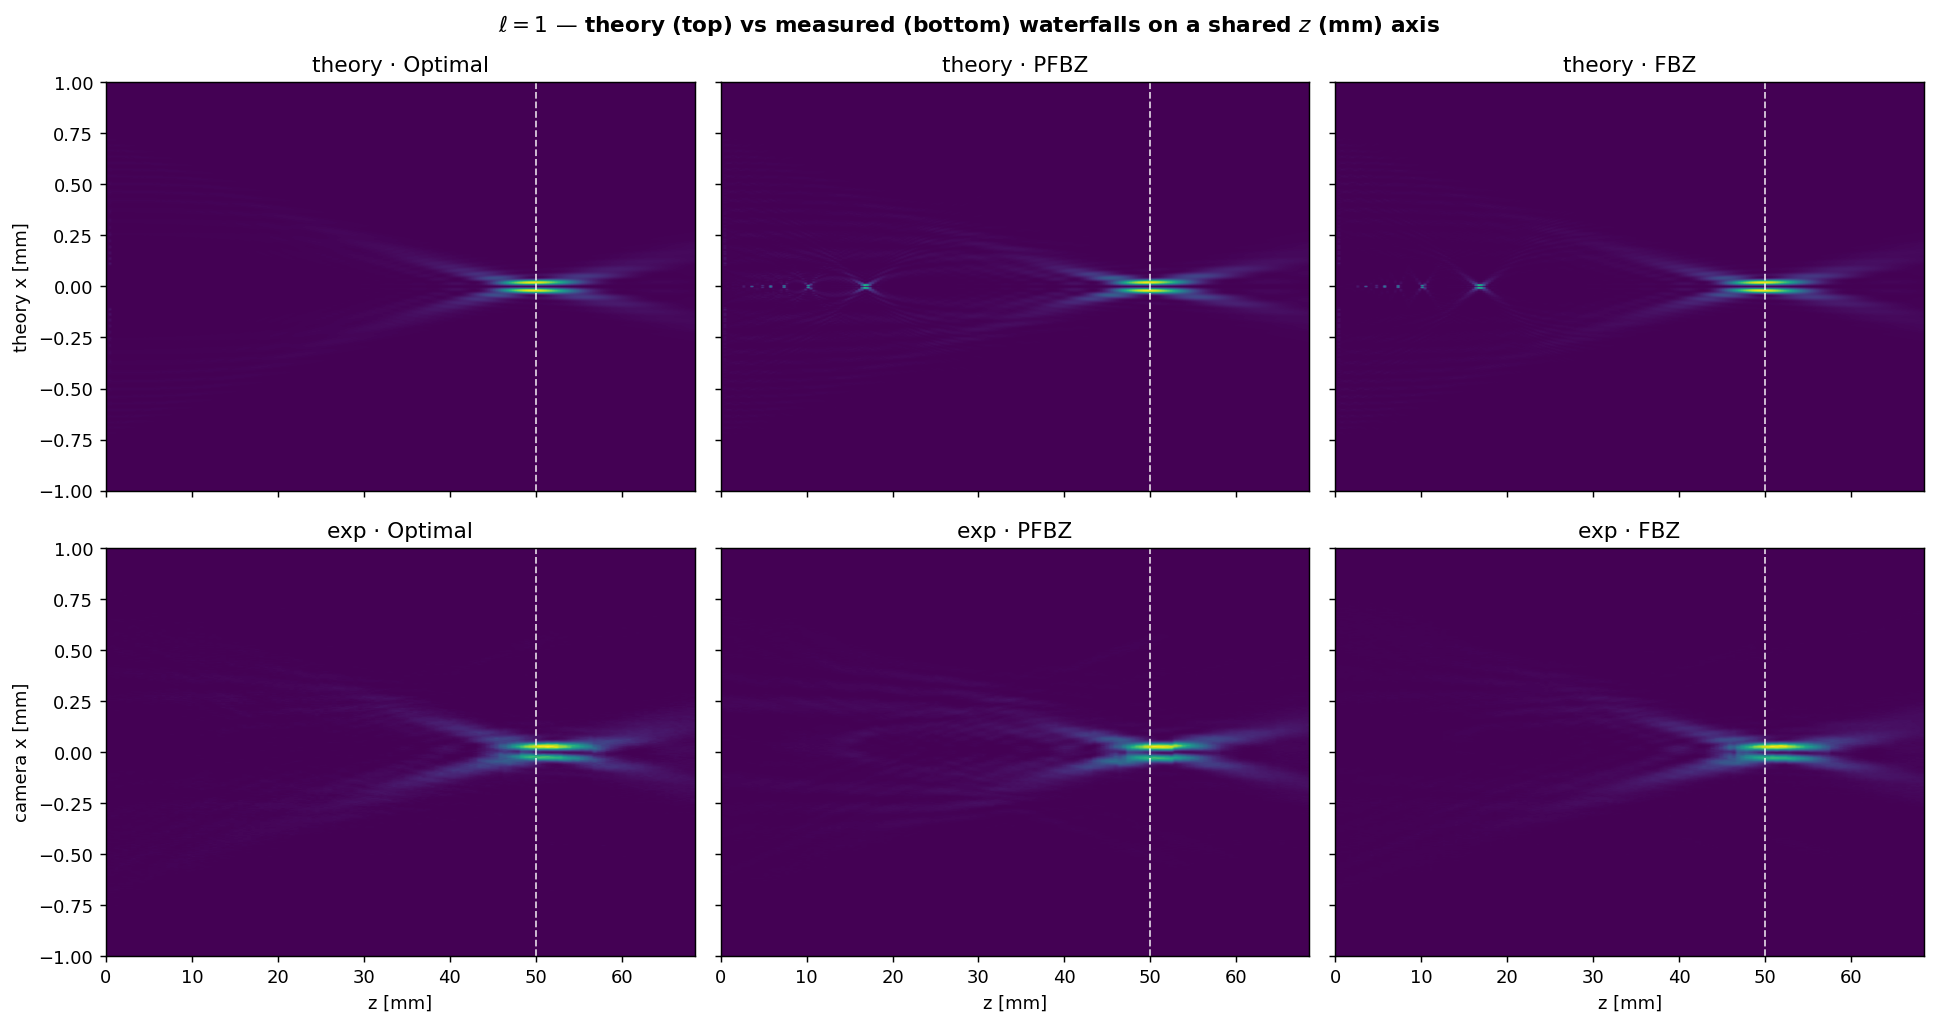

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col", sharey=True)
order3 = ["Optimal", "PFBZ", "FBZ"]
YLIM = 1.0     # mm shown, shared by both rows


def pad_to_window(waterfall, x_mm, half):
    """Zero-pad the transverse axis so the image spans [-half, half] mm exactly,
    so viridis' zero-level (purple) fills the frame with no white margin when the
    data window is narrower than the plot ylim."""
    x = np.asarray(x_mm, float)
    wf = np.asarray(waterfall, float)
    dx = float(np.median(np.diff(x)))
    n_lo = max(0, int(np.ceil((x[0] - (-half)) / dx)))
    n_hi = max(0, int(np.ceil((half - x[-1]) / dx)))
    if n_lo:
        wf = np.concatenate([np.zeros((wf.shape[0], n_lo)), wf], axis=1)
    if n_hi:
        wf = np.concatenate([wf, np.zeros((wf.shape[0], n_hi))], axis=1)
    return wf, (x[0] - n_lo * dx, x[-1] + n_hi * dx)


for c, name in enumerate(order3):
    # theory (top)
    tw = THEORY_WF[name]
    img, (x_lo, x_hi) = pad_to_window(tw["waterfall"], tw["x_mm"], YLIM)
    ax = axes[0, c]
    ax.imshow(img.T, origin="lower", aspect="auto",
              extent=[tw["z_mm"][0], tw["z_mm"][-1], x_lo, x_hi],
              cmap="viridis", vmin=0, vmax=1)
    ax.axvline(Z_FOCUS_REF_MM, color="w", ls="--", lw=1.0, alpha=0.8)
    ax.set_ylim(-YLIM, YLIM)
    ax.set_title(f"theory · {name}")
    if c == 0:
        ax.set_ylabel("theory x [mm]")

    # experiment (bottom)
    ew = EXP_WF[name]
    img, (x_lo, x_hi) = pad_to_window(ew["waterfall"], ew["x_mm"], YLIM)
    ax = axes[1, c]
    ax.imshow(img.T, origin="lower", aspect="auto",
              extent=[ew["z_mm"][0], ew["z_mm"][-1], x_lo, x_hi],
              cmap="viridis", vmin=0, vmax=1)
    ax.axvline(Z_FOCUS_REF_MM, color="w", ls="--", lw=1.0, alpha=0.8)
    ax.set_ylim(-YLIM, YLIM)
    ax.set_xlabel("z [mm]")
    ax.set_title(f"exp · {name}")
    if c == 0:
        ax.set_ylabel("camera x [mm]")

fig.suptitle(f"$\\ell={L}$ — theory (top) vs measured (bottom) waterfalls on a shared $z$ (mm) axis",
             fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "waterfalls_theory_vs_exp_z.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Notes & next steps

- **Theory cache.** The expensive propagation runs once in `theory_cache.py` and is stored in
  `outputs/theory_vs_experiment_l1/theory_l1_cache.npz`. Rerun `python theory_cache.py` (or set
  `FORCE_THEORY_RECOMPUTE=True`) only if you change `THEORY_GRID`, `L`, or `N0`. Tuning the aperture
  `A` or the axial scale never touches the cache.
- **Axial map.** Theory is placed on real $z$ via a single global scale, `THEORY_MM_PER_TAU`, which
  anchors $\tau_f\to$`Z_FOCUS_REF_MM` (default 50 mm ≈ the measured focus). Adjust `Z_FOCUS_REF_MM`
  to slide theory along $z$; adjust `A` to rescale theory width in mm.
- **Shared format.** Both theory and experiment are saved as `waterfalls/{theory,exp}_*.npz` with
  identical keys (`z_mm`, `x_mm`, `waterfall`, `width_mm`); load them back with `load_waterfall_npz`.
- **Transverse crop.** Experiment RMS/LG widths use the $\pm$`CROP_HALF_WIDTH` window; theory uses
  the full aperture. Widen the crop if you want the wings.
- **Extending to other $\ell$.** Only $\ell=1$ was recorded on 8-17-26; set `ELLS` and `L` together
  (the theory cache rebuilds automatically for the new `L`).
